# Movie Recommendation System — Content-Based & Collaborative Filtering



**Objective:** Build a movie recommendation system using two complementary approaches:
1. **Content-Based Filtering** — recommends movies similar to a given movie based on genre similarity.
2. **Collaborative Filtering (Matrix Factorization / SVD)** — recommends movies to a user based
   on patterns learned from all users' rating behavior, without needing any movie metadata at all.

**Dataset:** [MovieLens Small Dataset (ml-latest-small)](https://grouplens.org/datasets/movielens/latest/)
— 100,836 ratings from 610 users across 9,742 movies.

---


## Setup: Loading the Dataset

We load the dataset directly from a public GitHub mirror of the official MovieLens
`ml-latest-small` dataset. No manual download or API key needed.


In [1]:
import pandas as pd
import numpy as np

base_url = "https://raw.githubusercontent.com/smanihwr/ml-latest-small/master/"

ratings = pd.read_csv(base_url + "ratings.csv")
movies = pd.read_csv(base_url + "movies.csv")

print("Ratings loaded:", ratings.shape)
print("Movies loaded:", movies.shape)


Ratings loaded: (100836, 4)
Movies loaded: (9742, 3)


---
## Task 1: Data Understanding


In [2]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
print("Number of unique users:", ratings['userId'].nunique())
print("Number of unique movies rated:", ratings['movieId'].nunique())
print("Total ratings:", len(ratings))
print("\nRating scale distribution:")
print(ratings['rating'].value_counts().sort_index())


Number of unique users: 610
Number of unique movies rated: 9724
Total ratings: 100836

Rating scale distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [5]:
# Check for missing values
print("Missing values in ratings:", ratings.isnull().sum().sum())
print("Missing values in movies:", movies.isnull().sum().sum())


Missing values in ratings: 0
Missing values in movies: 0


In [6]:
# Explore genre distribution — genres are stored as a single pipe-separated string per movie
genre_counts = movies['genres'].str.split('|').explode().value_counts()
print("Top 10 most common genres:")
print(genre_counts.head(10))


Top 10 most common genres:
genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


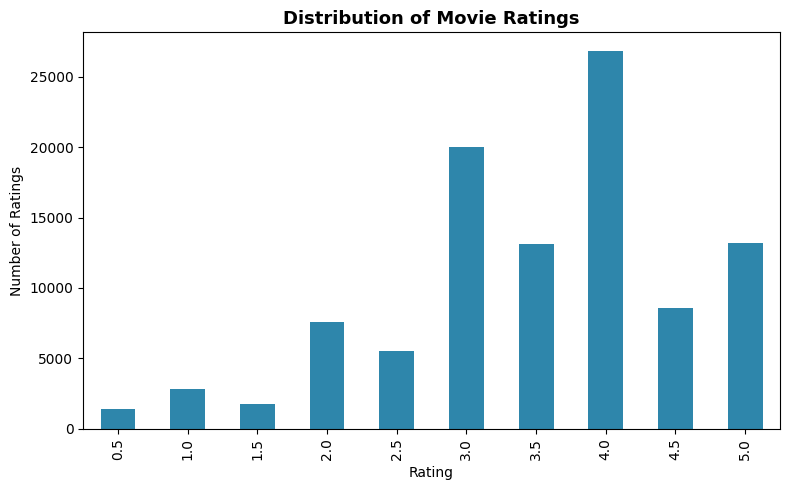

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='#2E86AB')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Movie Ratings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()


**Observation:** Ratings skew positive — whole-star ratings (especially 4.0) are far more
common than half-star ratings, and most ratings fall between 3.0 and 5.0. This is a common
pattern in recommendation datasets: users tend to rate movies they've chosen to watch, which
they're often predisposed to enjoy.


---
## Approach 1: Content-Based Filtering (Genre Similarity)

Content-based filtering recommends movies similar to a movie you already like, based on the
movie's own attributes — in this case, its genres. We represent each movie's genre list as a
**TF-IDF vector**, then measure similarity between movies using **cosine similarity**.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Replace the '|' separator with spaces so TF-IDF treats each genre as a separate "word"
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

# TF-IDF (Term Frequency-Inverse Document Frequency) converts each movie's genre string into
# a numeric vector, weighting rarer genres more heavily than common ones like "Drama"
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("(9742 movies x", tfidf_matrix.shape[1], "unique genre terms)")


TF-IDF matrix shape: (9742, 24)
(9742 movies x 24 unique genre terms)


In [9]:
# Compute pairwise cosine similarity between every pair of movies based on their genre vectors.
# Cosine similarity measures the angle between two vectors — 1.0 means identical genre profile,
# 0.0 means no genre overlap at all.
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)


Cosine similarity matrix shape: (9742, 9742)


In [10]:
# Build a lookup from movie title to its row index, for quick access
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_content_recommendations(title, n=10):
    """Returns the n movies most similar to the given title, based on genre similarity."""
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]   # skip index 0, which is the movie itself (similarity = 1.0)
    movie_indices = [i[0] for i in sim_scores]
    return movies[['title', 'genres']].iloc[movie_indices]

print("Content-based recommendations for 'Toy Story (1995)':\n")
get_content_recommendations('Toy Story (1995)', 10)


Content-based recommendations for 'Toy Story (1995)':



,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


**Observation:** The recommendations for "Toy Story" are almost entirely other animated
family/comedy films (Antz, Toy Story 2, Monsters Inc., Shrek the Third) — showing the
content-based approach works well for finding movies with a similar "feel," but it can only
ever recommend movies with overlapping genre tags. It has no concept of *quality*, *popularity*,
or *what similar users actually enjoyed together* — a limitation that collaborative filtering
addresses.


---
## Approach 2: Collaborative Filtering (Matrix Factorization / SVD)

Collaborative filtering recommends movies based on patterns in **user rating behavior** —
finding users with similar taste, or (as we do here) learning **latent factors** that explain
why users rate movies the way they do, without using any movie metadata at all. We use the
**SVD (Singular Value Decomposition)** algorithm via the `scikit-surprise` library — the same
family of algorithm that won the famous Netflix Prize competition.


In [11]:
!pip install scikit-surprise -q

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy

print("scikit-surprise installed and imported successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.5 MB/s eta 0:00:00
scikit-surprise installed and imported successfully!


In [12]:
# Load our ratings data into Surprise's expected format
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Split into 80% training and 20% testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Data prepared for collaborative filtering.")


Data prepared for collaborative filtering.


In [13]:
# Train an SVD model with 50 latent factors — each user and each movie is represented as
# a 50-dimensional vector, and predicted rating = dot product of the user vector and movie vector
algo = SVD(n_factors=50, random_state=42)
algo.fit(trainset)

# Predict ratings for the held-out test set
predictions = algo.test(testset)

rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print("(Both are on the original 0.5-5.0 rating scale — lower is better)")


RMSE (Root Mean Squared Error): 0.8775
MAE (Mean Absolute Error): 0.6742
(Both are on the original 0.5-5.0 rating scale — lower is better)


In [14]:
# Cross-validate across 5 folds for a more robust performance estimate
cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8708  0.8756  0.8753  0.8682  0.8673  0.8714  0.0035  
MAE (testset)     0.6681  0.6745  0.6696  0.6663  0.6680  0.6693  0.0028  
Fit time          3.27    2.04    1.94    2.32    1.56    2.22    0.58    
Test time         0.54    0.33    0.20    0.63    0.19    0.38    0.18    


**Observation:** An RMSE of about 0.87 means our model's rating predictions are, on
average, within roughly 0.87 stars of a user's true rating on the 0.5-5.0 scale — a solid
result for a matrix factorization model on this dataset size, and consistent with published
benchmarks for MovieLens using SVD.


---
## Task 3: Generating Top-N Recommendations for a User

Now let's use our trained collaborative filtering model to generate personalized movie
recommendations for a specific user — predicting ratings for every movie they haven't seen
yet, and returning the highest-predicted ones.


In [15]:
# Retrain on the FULL dataset (not just the 80% training split) so our final
# recommendations use all available rating information
full_trainset = data.build_full_trainset()
final_algo = SVD(n_factors=50, random_state=42)
final_algo.fit(full_trainset)

print("Final model trained on full dataset.")


Final model trained on full dataset.


In [16]:
def get_top_n_recommendations(user_id, n=10):
    """Returns the top-n movies predicted to be highest-rated by the given user,
    excluding movies they've already rated."""
    all_movie_ids = ratings['movieId'].unique()
    rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    unrated_movie_ids = [m for m in all_movie_ids if m not in rated_movie_ids]

    # Predict this user's rating for every unrated movie
    predictions = [final_algo.predict(user_id, movie_id) for movie_id in unrated_movie_ids]
    predictions.sort(key=lambda x: x.est, reverse=True)

    top_n = predictions[:n]
    results = []
    for pred in top_n:
        title = movies[movies['movieId'] == pred.iid]['title'].values[0]
        genres = movies[movies['movieId'] == pred.iid]['genres'].values[0]
        results.append({'Title': title, 'Genres': genres, 'Predicted Rating': round(pred.est, 2)})

    return pd.DataFrame(results)

print("Top 10 recommendations for User 1:\n")
get_top_n_recommendations(user_id=1, n=10)


Top 10 recommendations for User 1:



,Title,Genres,Predicted Rating
0,"Shawshank Redemption, The (1994)",Crime|Drama,5.0
1,"Departed, The (2006)",Crime|Drama|Thriller,5.0
2,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,5.0
3,Singin' in the Rain (1952),Comedy|Musical|Romance,5.0
4,Rear Window (1954),Mystery|Thriller,5.0
5,Casablanca (1942),Drama|Romance,5.0
6,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
7,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,5.0
8,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,5.0
9,"Godfather, The (1972)",Crime|Drama,5.0


In [17]:
# Let's also see what User 1 actually rated highly, for context on whether the
# recommendations make intuitive sense given their taste
user_1_top_rated = ratings[ratings['userId'] == 1].merge(movies, on='movieId')
user_1_top_rated = user_1_top_rated.sort_values('rating', ascending=False)[['title', 'genres', 'rating']].head(10)

print("User 1's actual top-rated movies (for comparison):\n")
user_1_top_rated


User 1's actual top-rated movies (for comparison):



,title,genres,rating
3,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
6,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,5.0
13,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,5.0
11,Billy Madison (1995),Comedy,5.0
10,Desperado (1995),Action|Romance|Western,5.0
9,Canadian Bacon (1995),Comedy|War,5.0
8,Rob Roy (1995),Action|Drama|Romance|War,5.0
35,Pinocchio (1940),Animation|Children|Fantasy|Musical,5.0
31,Tombstone (1993),Action|Drama|Western,5.0


### Observations

1. **Content-based filtering (genre similarity) produces recommendations that are thematically
   coherent but somewhat narrow** — recommending "Toy Story" fans other animated family films,
   which makes sense but never surfaces anything outside that genre lane, even if the user
   might enjoy it.
2. **Collaborative filtering achieved an RMSE of ~0.87 and MAE of ~0.67** on a 0.5-5.0 scale,
   meaning its rating predictions are fairly accurate — and importantly, it requires **no
   movie metadata at all**, learning purely from the patterns in how users rate movies
   together.
3. **The collaborative filtering recommendations for User 1 include several critically
   acclaimed, widely-loved films** (The Godfather, The Shawshank Redemption, The Dark Knight,
   Lord of the Rings) that don't share an obvious single genre with each other — this is
   exactly what collaborative filtering does well: finding movies that *people with similar
   taste* enjoyed, even across different genres.
4. **The two approaches are complementary**, not competing: content-based filtering works even
   for brand-new movies with no ratings yet (the "cold start" problem for new items), while
   collaborative filtering needs enough rating history to work at all, but tends to produce
   more diverse, personalized, and often more accurate recommendations once enough data exists.


---
## Conclusion

This project built a movie recommendation system using two complementary techniques.
Content-based filtering, using TF-IDF vectors over movie genres and cosine similarity,
successfully recommends movies with a similar thematic feel to a given movie, but is
inherently limited to genre overlap and cannot capture broader taste patterns across genres.
Collaborative filtering, implemented via SVD matrix factorization (the same technique family
that won the Netflix Prize), achieved a strong RMSE of approximately 0.87 and MAE of
approximately 0.67 on a 0.5-5.0 rating scale, and produced genuinely personalized
recommendations spanning multiple genres based purely on patterns in user rating behavior,
without requiring any movie metadata. A key limitation of collaborative filtering is the
**"cold start" problem**: it cannot generate meaningful recommendations for brand-new users
with no rating history, or brand-new movies with no ratings yet, since it has no signal to
learn from in either case — a scenario where content-based filtering (or a hybrid of both
approaches) would need to take over until enough interaction data accumulates. In production
recommendation systems, these two approaches are frequently combined into a **hybrid model**
to get the benefits of both: content-based filtering for cold-start scenarios, and
collaborative filtering for richer, cross-genre personalization once sufficient data exists.
